In [1]:
import pandas as pd
import numpy as np

def find_high_activity_ids(file_path, min_active_bits=40):
    """
    Scans a CAN log to find IDs where at least 'min_active_bits' out of 64 
    show activity (flipping).
    """
    print(f"Scanning {file_path} for active IDs...")
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    
    # Split ID and Payload: "0D0#A1B2..." -> ["0D0", "A1B2..."]
    split_data = df['raw_frame'].str.split('#', expand=True)
    df['can_id'] = split_data[0]
    df['payload'] = split_data[1]
    
    results = []
    unique_ids = df['can_id'].unique()

    for target_id in unique_ids:
        df_target = df[df['can_id'] == target_id]
        if len(df_target) < 100: continue # Skip IDs with low sample size
        payloads = df_target['payload'].values
        
        def hex_to_bit_array(hex_str):
            return np.array([int(b) for b in bin(int(hex_str, 16))[2:].zfill(64)], dtype=np.int8)

        # Process bits for this ID
        bit_data = np.stack([hex_to_bit_array(p) for p in payloads])
        
        # Calculate flips per bit position
        active_bit_mask = (bit_data[1:] != bit_data[:-1]).any(axis=0)
        active_count = active_bit_mask.sum()
        
        if active_count >= min_active_bits:
            results.append({
                'id': '0x'+target_id,
                'dbc_id': int(target_id,16),
                'active_bits': active_count,
                'total_frames': len(df_target)
            })
            print(f"FOUND: ID {target_id} has {active_count} active bits!")

    # Sort by activity
    found_df = pd.DataFrame(results).sort_values(by='active_bits', ascending=False)
    return found_df
    
log_path='logs/1_2018 Holden Astra/driving/2_driving_CAN_continuous.log'
top_ids = find_high_activity_ids(log_path, min_active_bits=25)

print("\n--- Top Active Candidates for Unseen ID ---")
print(top_ids)

Scanning logs/1_2018 Holden Astra/driving/1_driving_CAN_continuous.log for active IDs...
FOUND: ID 0C5 has 60 active bits!
FOUND: ID 0C9 has 36 active bits!
FOUND: ID 0D1 has 26 active bits!
FOUND: ID 1C8 has 29 active bits!
FOUND: ID 18E has 43 active bits!
FOUND: ID 1E9 has 27 active bits!
FOUND: ID 1FC has 59 active bits!
FOUND: ID 1AA has 29 active bits!
FOUND: ID 214 has 31 active bits!
FOUND: ID 1BA has 54 active bits!
FOUND: ID 0F1 has 27 active bits!
FOUND: ID 1C3 has 35 active bits!
FOUND: ID 1C4 has 37 active bits!
FOUND: ID 1C5 has 37 active bits!
FOUND: ID 0C7 has 26 active bits!
FOUND: ID 1E5 has 41 active bits!
FOUND: ID 0F9 has 51 active bits!
FOUND: ID 0C1 has 60 active bits!
FOUND: ID 0BE has 33 active bits!
FOUND: ID 189 has 49 active bits!
FOUND: ID 19D has 45 active bits!
FOUND: ID 2F1 has 33 active bits!
FOUND: ID 2C3 has 29 active bits!
FOUND: ID 3D1 has 28 active bits!
FOUND: ID 3D3 has 28 active bits!
FOUND: ID 2F9 has 25 active bits!
FOUND: ID 3E9 has 50 active

In [2]:
Holden_Ground_Labels = {

    # ---------------------------------------------------------
    # 0x075 — STEER_RELATED (ID 117)
    # ---------------------------------------------------------
    '0C5': [
        # Byte 0 (CTR)
        2,2,2,2,2,2,2,2,
        # Byte 1 (STEER_TORQUE)
        0,0,0,0,0,0,0,0,
        # Byte 2 (STEER_TORQUE + STEER_ANGLE_2)
        0,0,0,0,3,3,3,3,
        # Byte 3 (STEER_ANGLE_2)
        3,3,3,3,3,3,3,3,
        # Byte 4 (STEER_ANGLE_2)
        0,1,1,1,3,3,3,3,
        # Byte 5 (flags)
        3,3,3,3,3,3,3,3,
        # Byte 6 (flags)
        0,0,0,0,1,1,1,1,
        # Byte 7 (spare)
        0,0,0,0,0,0,0,0
    ],

    # ---------------------------------------------------------
    # 0x076 — RPM_RELATED (ID 118)
    # ---------------------------------------------------------
    '0C1': [
        # Byte 0 (CTR)
        2,2,2,2,2,2,2,2,
        # Byte 1 (NEW_SIGNAL_2)
        0,0,0,0,0,0,0,0,
        # Byte 2 (NEW_SIGNAL_2)
        0,0,0,0,3,3,3,3,
        # Byte 3–7 (spare)
        3,3,3,3,3,3,3,3,
        0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0
    ],

    # ---------------------------------------------------------
    # 0x202 — ENGINE_DATA (ID 514)
    # ---------------------------------------------------------
    '1FC': [
        # Byte 0 (RPM)
        0,0,3,3,3,3,3,3,
        # Byte 1 (RPM)
        3,3,3,3,3,0,0,0,
        # Byte 2 (SPEED)
        0,0,3,3,3,3,3,3,
        # Byte 3 (SPEED)
        3,3,3,3,3,3,3,3,
        # Byte 4 (PEDAL_GAS)
        3,3,3,3,3,3,3,3,
        # Byte 5 (PEDAL_GAS)
        3,3,0,0,0,0,0,0,
        # Byte 6 (spare)
        0,0,0,0,0,0,0,0,
        # Byte 7 (checksum)
        4,4,4,4,4,4,4,4
    ],

    # ---------------------------------------------------------
    # 0x165 — PEDALS (ID 357)
    # ---------------------------------------------------------
    '1BA': [
        # Byte 0 (ACC + brake flags)
        1,1,0,1,0,0,0,1,
        # Byte 1 (more brake flags)
        1,0,0,0,0,0,0,0,
        # Byte 2 (standstill)
        0,0,0,0,0,0,0,3,
        # Byte 3 (misc flags)
        3,3,3,3,0,1,0,0,
        # Byte 4 (GEAR)
        0,0,0,0,0,0,0,0,
        # Byte 5–6 (spare)
        0,0,0,0 ,1,0,0,0,
        0,0,0,4,4,4,4,4,
        # Byte 7 (checksum)
        4,4,4,4,4,4,4,4
    ]
}


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

class CANClassificationDataset(Dataset):
    def __init__(self, sequences, labels):
        """
        sequences shape: (Samples, Window_Size, 64)
        labels shape: (Samples, 64) 
        """
        # Store the lightweight numpy arrays directly
        self.X = sequences
        self.y = labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Convert to PyTorch tensors dynamically, one batch at a time
        x_tensor = torch.tensor(self.X[idx], dtype=torch.float32)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.long)
        return x_tensor, y_tensor

def get_labeled_dataloaders(file_path, labels_dict, window_size=200, window_stride=10, batch_size=256):
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    
    all_x = []
    all_y = []
    
    def hex_to_bit_array(hex_str):
        # Converts hex payload to 64 individual bits
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.int8)

    for target_id, bit_labels in labels_dict.items():
        # Filter for specific CAN ID
        df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
        if len(df_target) < window_size: continue
        
        payloads = df_target['raw_frame'].str.split('#').str[1]
        bit_data = np.stack(payloads.apply(hex_to_bit_array).values) # Shape (N_frames, 64)

        # Create stride 
        # New Shape: (Number_of_Windows, Window_Size, 64)
        shape = ((bit_data.shape[0] - window_size) // window_stride + 1, window_size, 64)
        strides = (bit_data.strides[0] * window_stride, bit_data.strides[0], bit_data.strides[1])
        windows = np.lib.stride_tricks.as_strided(bit_data, shape=shape, strides=strides) 

        # Map Labels
        labels_array = np.array(bit_labels) # Shape (64,)
        #repeat labels for every window generated for this ID
        target_y = np.tile(labels_array, (windows.shape[0], 1)) 
        
        all_x.append(windows)
        all_y.append(target_y)
    
    X = np.concatenate(all_x, axis=0)
    y = np.concatenate(all_y, axis=0)
    
    train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, shuffle=True)
    # print(train_x)
    train_dl = DataLoader(CANClassificationDataset(train_x, train_y), batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(CANClassificationDataset(test_x, test_y), batch_size=batch_size, shuffle=False)
    
    print(f"Total Windows: {len(y)} | Input Shape: {X.shape[1:]}")
    return train_dl, test_dl

train_dl, test_dl = get_labeled_dataloaders(log_path,Holden_Ground_Labels)

Total Windows: 41562 | Input Shape: (200, 64)


0C5
Extracting 500 frames starting from index 106888 (out of 160151 total)


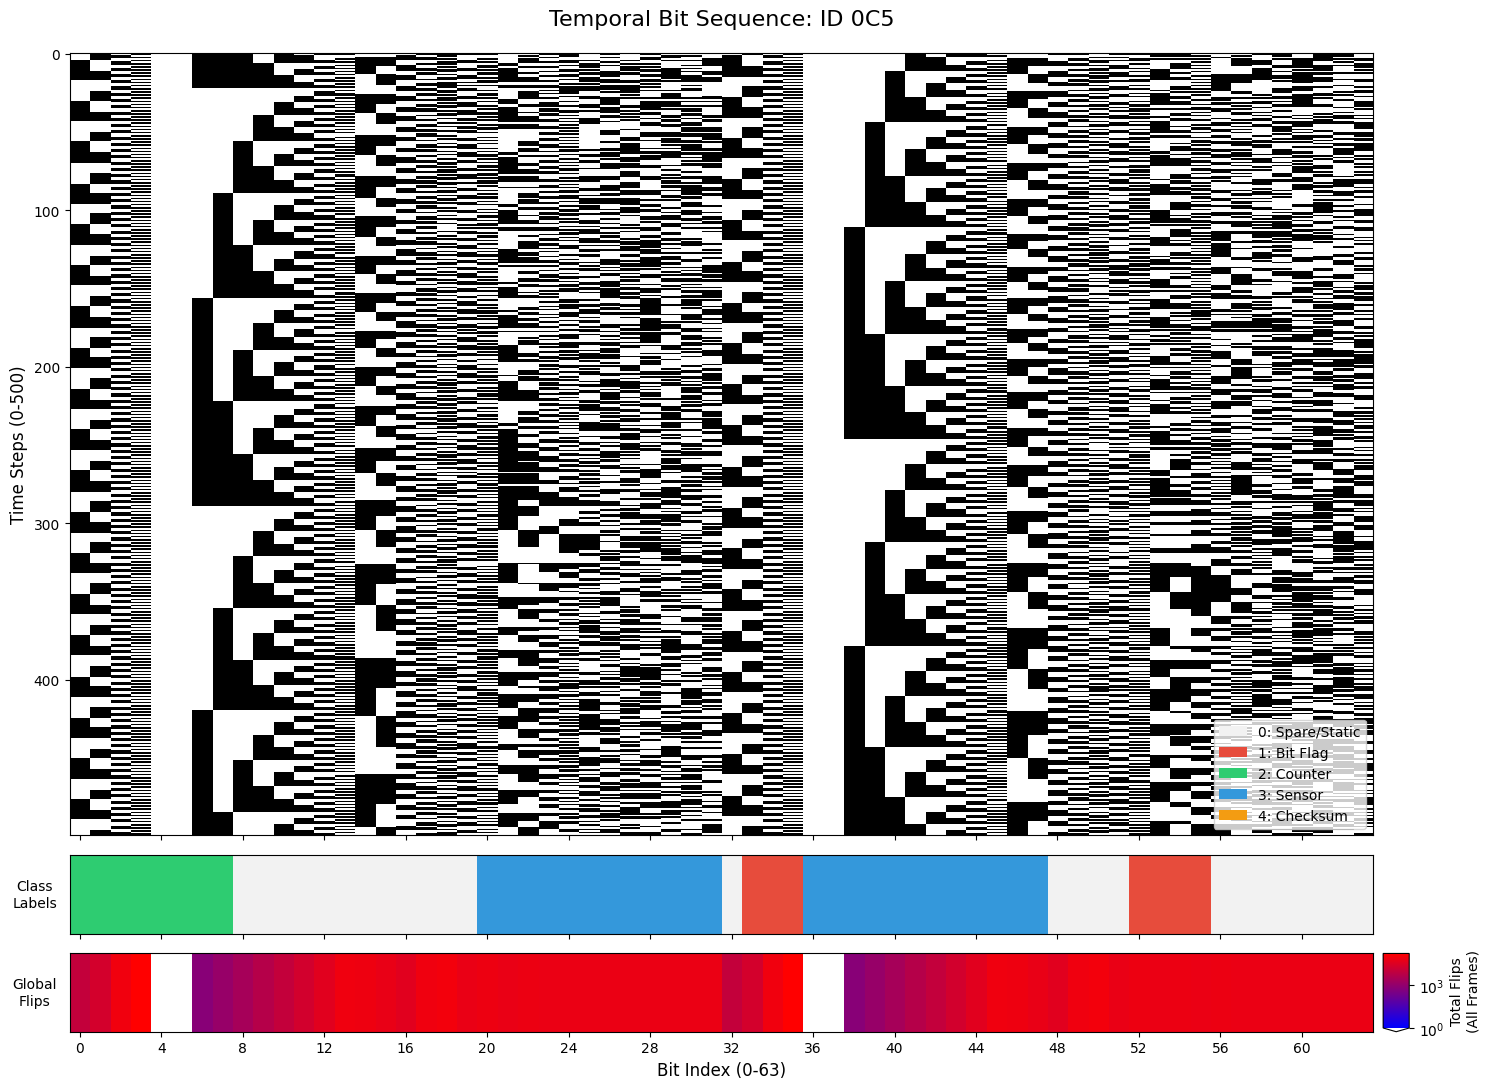

0C1
Extracting 500 frames starting from index 106888 (out of 160150 total)


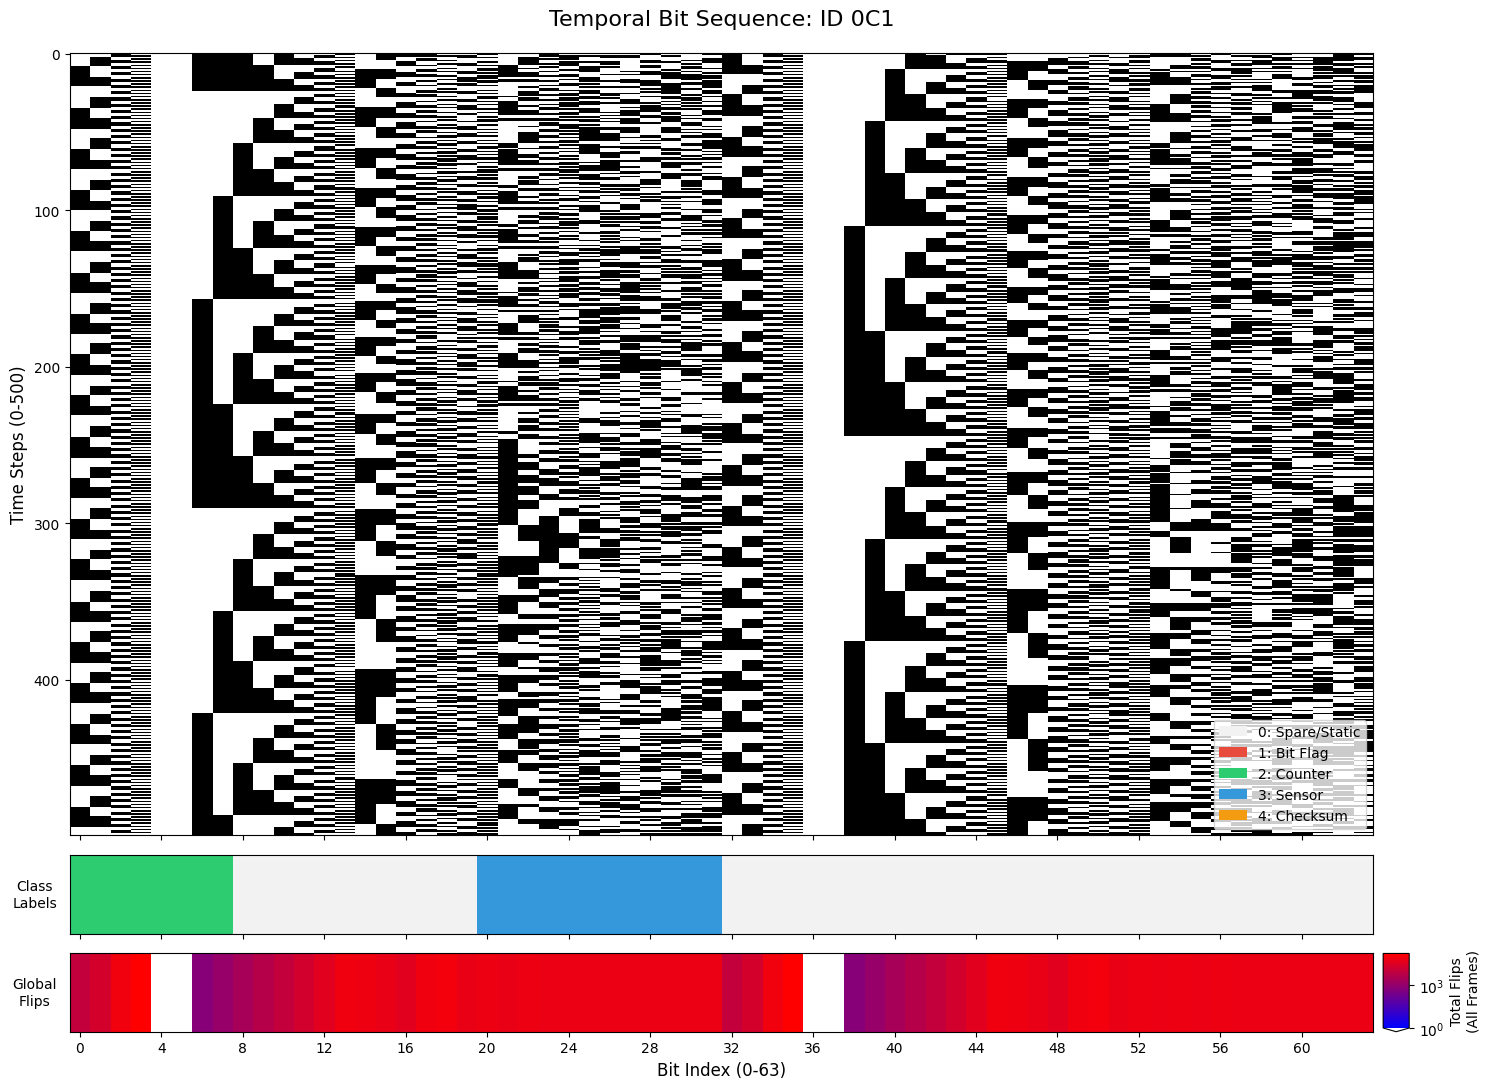

1FC
Extracting 500 frames starting from index 8584 (out of 32031 total)


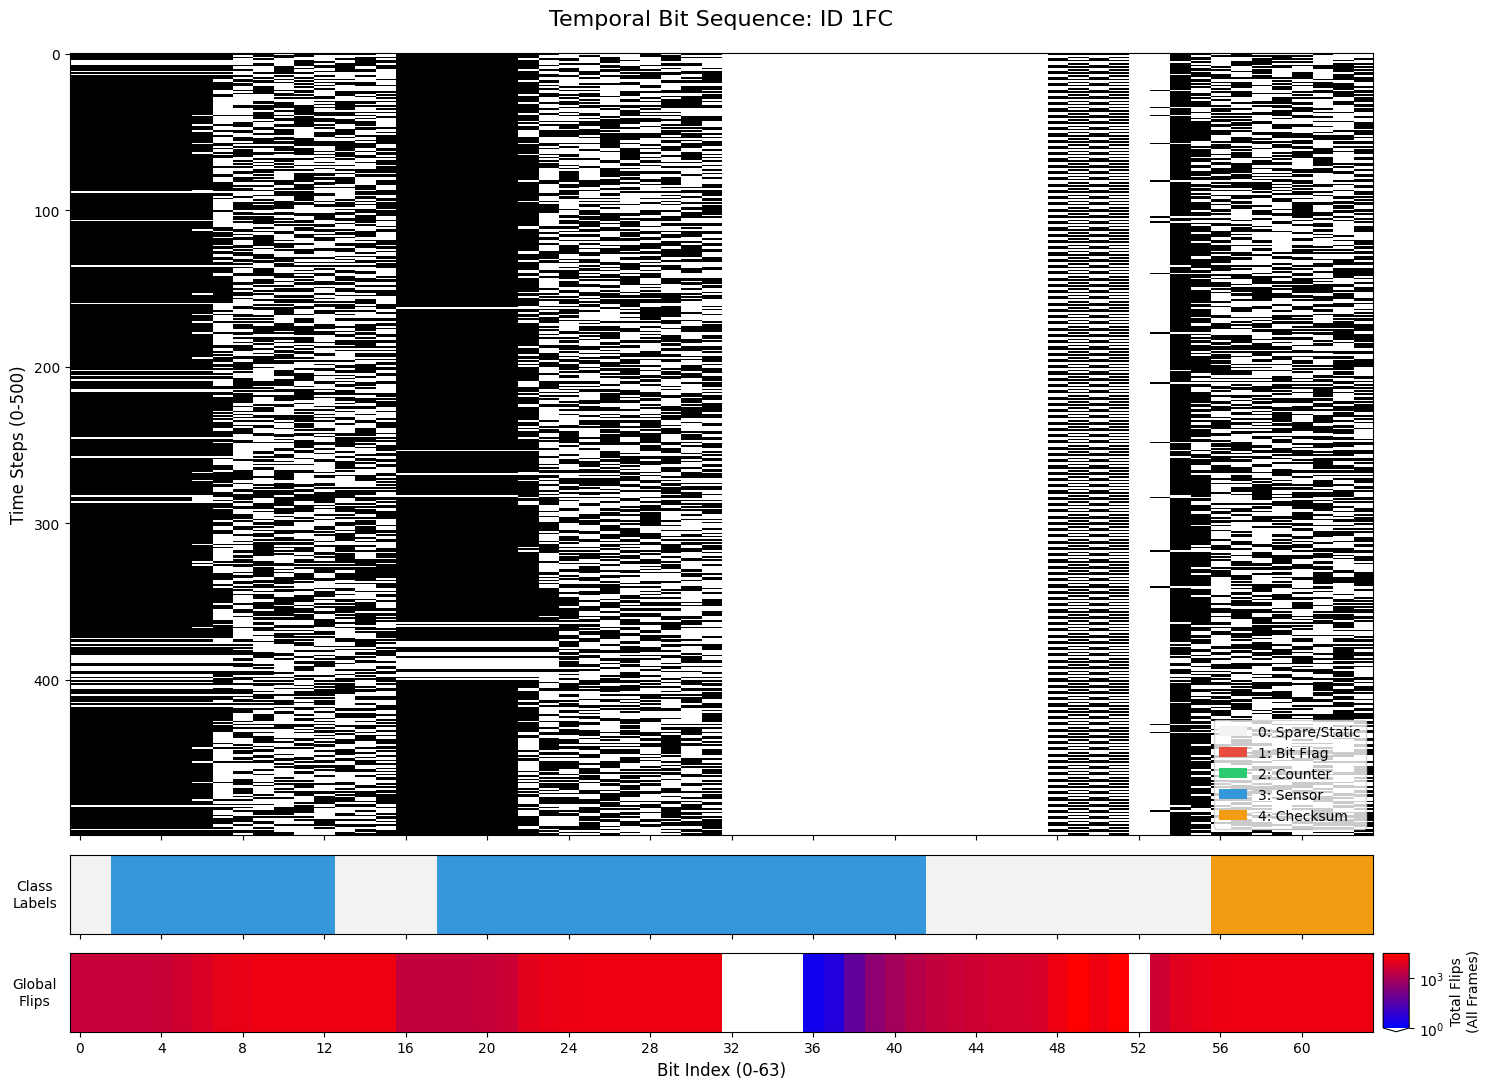

1BA
Extracting 500 frames starting from index 41352 (out of 64055 total)


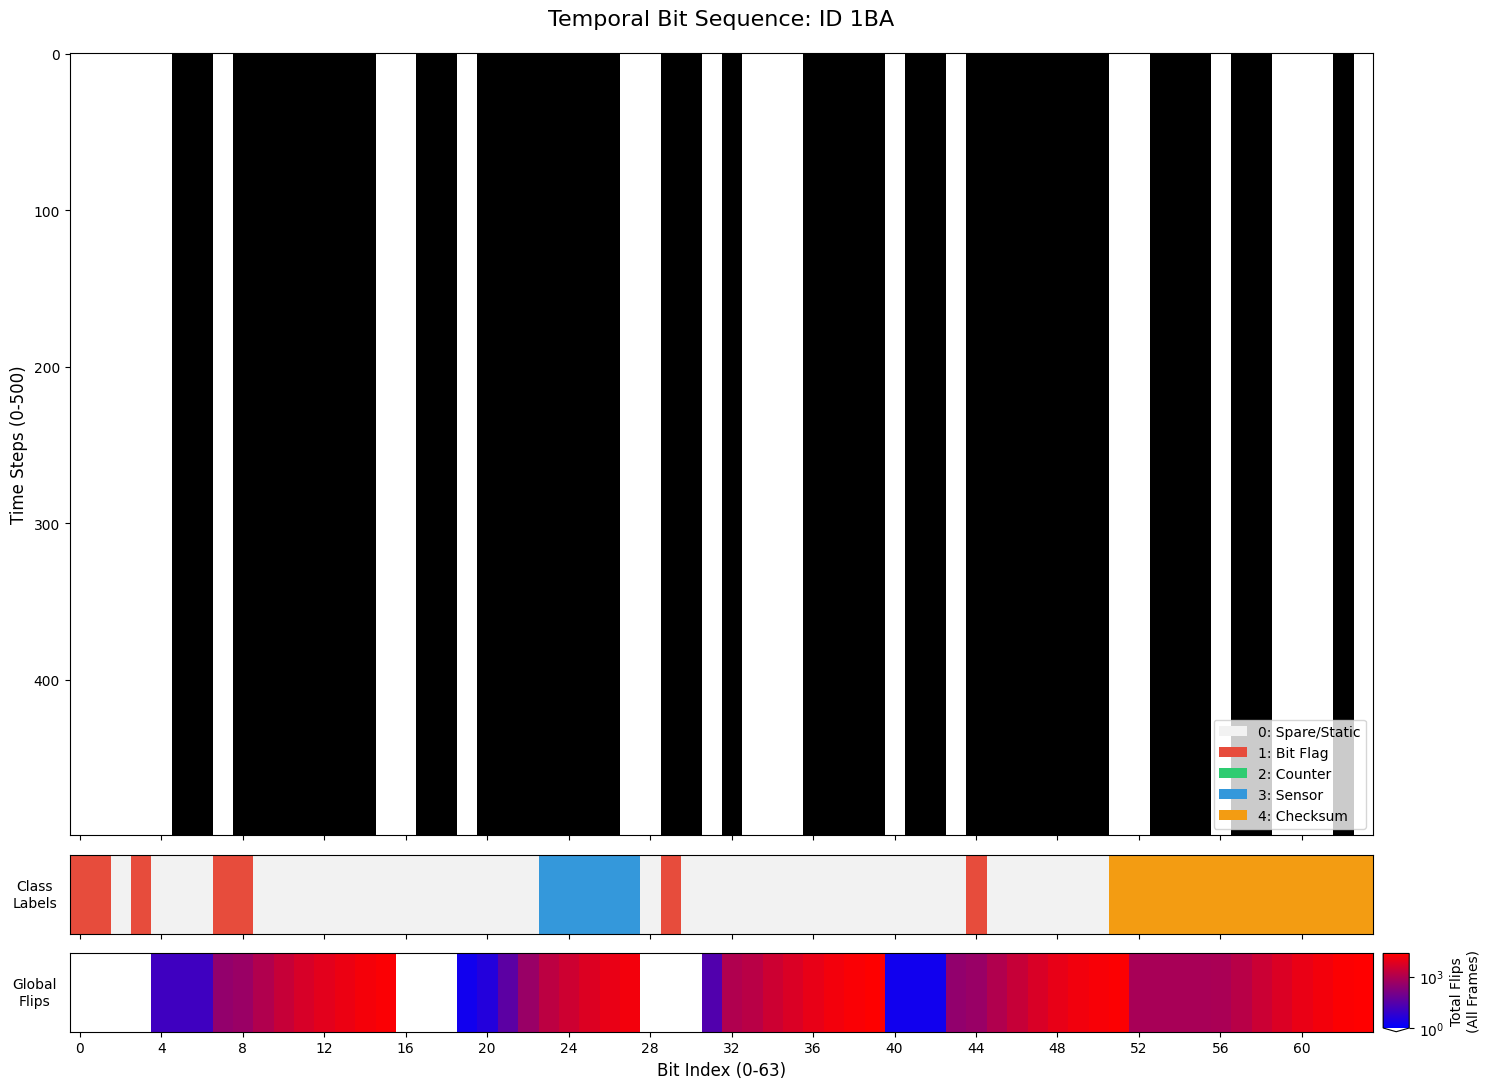

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd

def get_global_bit_flips(file_path, target_id):
    """
    Reads the raw log file, extracts all payloads for a specific CAN ID,
    and calculates the total number of bit flips (0->1 or 1->0) across all frames.
    """
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
    
    if len(df_target) < 2:
        return np.zeros(64) 
        
    payloads = df_target['raw_frame'].str.split('#').str[1]
    
    def hex_to_bit_array(hex_str):
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.int64)

    bit_data = np.stack(payloads.apply(hex_to_bit_array).values) 
    bit_flips = (bit_data[1:] != bit_data[:-1]).sum(axis=0)
    return bit_flips


def plot_labeled_window(window_tensor, bit_labels, can_id, global_flips):
    """
    Plots a CAN bit heatmap, a global bit-flip heatmap, and a color-coded label strip.
    """
    from matplotlib.colors import LogNorm
    
    # Prepare Main Window Data
    data = window_tensor.numpy() if hasattr(window_tensor, 'numpy') else np.array(window_tensor)
    time_steps, bits = data.shape 
    bit_flips_2d = global_flips.reshape(1, -1) 
    
    # Setup figure with 3 Subplots
    fig, (ax1, ax3, ax2) = plt.subplots(3, 1, figsize=(15, 11), 
                                       gridspec_kw={'height_ratios': [10, 1, 1]},
                                       sharex=True)
    
    # Plot the Main Bit Sequence (The Window)
    ax1.imshow(data, aspect='auto', cmap='binary', interpolation='nearest')
    ax1.set_title(f"Temporal Bit Sequence: ID {can_id}", fontsize=16, pad=20)
    ax1.set_ylabel(f"Time Steps (0-{time_steps})", fontsize=12)
    
    # Plot the Label Strip (ax3)
    class_colors = ['#f2f2f2', '#e74c3c', '#2ecc71', '#3498db', '#f39c12']
    cmap_labels = mcolors.ListedColormap(class_colors)
    label_strip = np.array(bit_labels).reshape(1, -1)
    ax3.imshow(label_strip, aspect='auto', cmap=cmap_labels, vmin=0, vmax=4)
    ax3.set_yticks([]) 
    ax3.set_ylabel("Class\nLabels", fontsize=10, rotation=0, labelpad=25, va='center')
    
    # Plot the Global Bit Flips (ax2)
    # Create a gradient from Blue to Red
    cmap_flips = mcolors.LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])
    # Force anything below our minimum (1) to be white
    cmap_flips.set_under("white")
    im_flips = ax2.imshow(bit_flips_2d, aspect='auto', cmap=cmap_flips, vmin=1, vmax=global_flips.max())

    
    # Find the max flips
    max_flips = max(global_flips.max(),10)
    
    im_flips = ax2.imshow(
        bit_flips_2d, 
        aspect='auto', 
        cmap=cmap_flips, 
        norm=LogNorm(vmin=1, vmax=max_flips)
    )

    ax2.set_yticks([]) 
    ax2.set_xlabel("Bit Index (0-63)", fontsize=12) 
    ax2.set_ylabel("Global\nFlips", fontsize=10, rotation=0, labelpad=25, va='center')

    div1 = make_axes_locatable(ax1)
    cax1 = div1.append_axes("right", size="2%", pad=0.1)
    cax1.axis('off')

    div2 = make_axes_locatable(ax3)
    cax3 = div2.append_axes("right", size="2%", pad=0.1)
    cax3.axis('off') 

    div3 = make_axes_locatable(ax2)
    cax2 = div3.append_axes("right", size="2%", pad=0.1)
    
    cbar = fig.colorbar(im_flips, cax=cax2, extend='min')
    cbar.set_label('Total Flips\n(All Frames)', fontsize=10)

    legend_elements = [
        Patch(facecolor=class_colors[0], label='0: Spare/Static'),
        Patch(facecolor=class_colors[1], label='1: Bit Flag'),
        Patch(facecolor=class_colors[2], label='2: Counter'),
        Patch(facecolor=class_colors[3], label='3: Sensor'),
        Patch(facecolor=class_colors[4], label='4: Checksum'),
    ]
    ax1.legend(handles=legend_elements, loc='lower right')

    ax2.set_xlim(-0.5, 63.5)
    ax2.set_xticks(range(0, 64, 4))
    
    plt.tight_layout()
    plt.show()

def get_single_window_for_id(file_path, target_id, window_size=50, seed=1669436):
    """Grab a random contiguous window for a specific ID to plot."""
    df = pd.read_csv(file_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])
    df_target = df[df['raw_frame'].str.contains(f"^{target_id}#")].copy()
    
    total_frames = len(df_target)
    
    if total_frames < window_size:
        print(f"Not enough data for ID {target_id}. Found {total_frames}, need {window_size}.")
        return None

    if seed is not None:
        np.random.seed(seed)
        
    max_start_idx = total_frames - window_size
    start_idx = np.random.randint(0, max_start_idx + 1) if max_start_idx > 0 else 0
    print(f"Extracting {window_size} frames starting from index {start_idx} (out of {total_frames} total)")
    
    payloads = df_target['raw_frame'].str.split('#').str[1].iloc[start_idx : start_idx + window_size]
    
    def hex_to_bit_array(hex_str):
        binary_str = bin(int(hex_str, 16))[2:].zfill(64)
        return np.array([int(b) for b in binary_str], dtype=np.float32)

    return np.stack(payloads.apply(hex_to_bit_array).values)

# Plot Each Decode CAN Payload
for target_id in Holden_Ground_Labels:
    print(target_id)
    labels_list = Holden_Ground_Labels[target_id]
    window_tensor = get_single_window_for_id(log_path, target_id, window_size=500)
    global_flips = get_global_bit_flips(log_path, target_id)
    plot_labeled_window(window_tensor, labels_list, target_id, global_flips)